# Airbnb Project 

### By Kuan-Yu, HOU

In [3]:
# step 1 : import libreries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
# Read the CSV file
data = pd.read_csv('AirBnb.csv')
data

,Unnamed: 0,listing_id,id,date,reviewer_id,reviewer_name,comments,Satisfaction_Livel,Satisfaction_Score_5,Recommandation_Score_5,Comeback
0,0,1178162,4724140,2013-05-21,4298113,Olivier,My stay at islam's place was really cool! Good...,Satisfait,3.470052,3.896255,Comeback
1,1,1178162,4869189,2013-05-29,6452964,Charlotte,Great location for both airport and city - gre...,Satisfait,4.000000,2.959623,Comeback
2,2,1178162,5003196,2013-06-06,6449554,Sebastian,We really enjoyed our stay at Islams house. Fr...,Neutre,3.001302,3.443672,No Comeback
3,3,1178162,5150351,2013-06-15,2215611,Marine,The room was nice and clean and so were the co...,Satisfait,3.458333,2.084004,Comeback
4,4,1178162,5171140,2013-06-16,6848427,Andrew,Great location. Just 5 mins walk from the Airp...,Satisfait,3.666667,2.275422,Comeback
...,...,...,...,...,...,...,...,...,...,...,...
68396,68396,8536127,76394660,2016-05-27,72475516,Prakash D,We had smooth check in at Apartment. We were p...,Neutre,3.105417,2.846640,No Comeback
68397,68397,1956275,32160313,2015-05-15,4143054,Amith,Emmanuel was a very good host. Had booked the ...,Satisfait,3.518750,3.583337,Comeback
68398,68398,13062783,98728297,2016-09-01,31264160,Marina,Michael was extremely nice! From picking me up...,Satisfait,3.701389,4.019198,Comeback
68399,68399,798957,11675670,2014-04-11,3033862,Ajev,Ed \r\n\r\nAwesome stay ! Recommended 300% to ...,Très Satisfait,5.000000,4.148623,Comeback


In [5]:
# data information 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68401 entries, 0 to 68400
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              68401 non-null  int64  
 1   listing_id              68401 non-null  int64  
 2   id                      68401 non-null  int64  
 3   date                    68401 non-null  object 
 4   reviewer_id             68401 non-null  int64  
 5   reviewer_name           68401 non-null  object 
 6   comments                68348 non-null  object 
 7   Satisfaction_Livel      68401 non-null  object 
 8   Satisfaction_Score_5    68401 non-null  float64
 9   Recommandation_Score_5  68401 non-null  float64
 10  Comeback                68401 non-null  object 
dtypes: float64(2), int64(4), object(5)
memory usage: 5.7+ MB


In [6]:
data.shape

(68401, 11)

# Cleaning process

In [8]:
# drop columns
data = data.drop(['Unnamed: 0'], axis = 1)

In [9]:
data.columns

Index(['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments',
       'Satisfaction_Livel', 'Satisfaction_Score_5', 'Recommandation_Score_5',
       'Comeback'],
      dtype='object')

In [10]:
# to convert date column
data.date =  pd.to_datetime(data.date)
data["date"]

0       2013-05-21
1       2013-05-29
2       2013-06-06
3       2013-06-15
4       2013-06-16
           ...    
68396   2016-05-27
68397   2015-05-15
68398   2016-09-01
68399   2014-04-11
68400   2016-06-01
Name: date, Length: 68401, dtype: datetime64[ns]

In [11]:
# list of missing values by column 
data.isnull().sum()

listing_id                 0
id                         0
date                       0
reviewer_id                0
reviewer_name              0
comments                  53
Satisfaction_Livel         0
Satisfaction_Score_5       0
Recommandation_Score_5     0
Comeback                   0
dtype: int64

In [12]:
# 刪除包含空值（NaN）的列
data = data.dropna()
data.shape

(68348, 10)

In [13]:
data.isnull().sum()

listing_id                0
id                        0
date                      0
reviewer_id               0
reviewer_name             0
comments                  0
Satisfaction_Livel        0
Satisfaction_Score_5      0
Recommandation_Score_5    0
Comeback                  0
dtype: int64

# a) Sentiment Analytics

In [15]:
data.columns

Index(['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments',
       'Satisfaction_Livel', 'Satisfaction_Score_5', 'Recommandation_Score_5',
       'Comeback'],
      dtype='object')

In [16]:
data.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,Satisfaction_Livel,Satisfaction_Score_5,Recommandation_Score_5,Comeback
0,1178162,4724140,2013-05-21,4298113,Olivier,My stay at islam's place was really cool! Good...,Satisfait,3.470052,3.896255,Comeback
1,1178162,4869189,2013-05-29,6452964,Charlotte,Great location for both airport and city - gre...,Satisfait,4.000000,2.959623,Comeback
2,1178162,5003196,2013-06-06,6449554,Sebastian,We really enjoyed our stay at Islams house. Fr...,Neutre,3.001302,3.443672,No Comeback
3,1178162,5150351,2013-06-15,2215611,Marine,The room was nice and clean and so were the co...,Satisfait,3.458333,2.084004,Comeback
4,1178162,5171140,2013-06-16,6848427,Andrew,Great location. Just 5 mins walk from the Airp...,Satisfait,3.666667,2.275422,Comeback


### 1. Extract sentiment:Identify the sentiment of each review (positive, neutral, or negative) and create a sentiment column.

In [18]:
from textblob import TextBlob

def get_sentiment(text):
    # 如果評論為空，則返回 "中立" 
    if pd.isna(text):
        return "Neutral"
    # 使用 TextBlob 分析情感得分
    sentiment_score = TextBlob(text).sentiment.polarity
    # 根據得分範圍返回情感標籤
    if sentiment_score > 0.1:
        return "Positive"
    elif sentiment_score < -0.1:
        return "Negative"
    else:
        return "Neutral"

# 對每條評論進行情感分析
data['Sentiment'] = data['comments'].apply(get_sentiment)

In [19]:
data.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,Satisfaction_Livel,Satisfaction_Score_5,Recommandation_Score_5,Comeback,Sentiment
0,1178162,4724140,2013-05-21,4298113,Olivier,My stay at islam's place was really cool! Good...,Satisfait,3.470052,3.896255,Comeback,Positive
1,1178162,4869189,2013-05-29,6452964,Charlotte,Great location for both airport and city - gre...,Satisfait,4.000000,2.959623,Comeback,Positive
2,1178162,5003196,2013-06-06,6449554,Sebastian,We really enjoyed our stay at Islams house. Fr...,Neutre,3.001302,3.443672,No Comeback,Positive
3,1178162,5150351,2013-06-15,2215611,Marine,The room was nice and clean and so were the co...,Satisfait,3.458333,2.084004,Comeback,Positive
4,1178162,5171140,2013-06-16,6848427,Andrew,Great location. Just 5 mins walk from the Airp...,Satisfait,3.666667,2.275422,Comeback,Positive


### 2. Identify recurring keywords:Find frequent keywords in reviews that indicate aspects customers appreciate or dislike.

In [21]:
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk

# 確保下載 nltk 的 stopwords 資料包
nltk.download('stopwords')

# 定義停用詞清單
# 停用詞是指在文本處理中，通常會被忽略的常用詞
stop_words = set(stopwords.words('english'))

# 取得所有評論文字，並將它們合併成一個字符串
all_comments = ' '.join(data['comments'].dropna())

# 清理文字：將文字轉為小寫並去除非字母字符
words = re.findall(r'\b\w+\b', all_comments.lower())

# 移除停用詞，只保留有意義的關鍵詞
filtered_words = [word for word in words if word not in stop_words]

# 計算每個詞的出現次數
word_counts = Counter(filtered_words)

# 顯示最常見的20個詞語
print("Top 20 keywords:", word_counts.most_common(20))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/houguanyu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 20 keywords: [('great', 40470), ('stay', 35577), ('boston', 32794), ('place', 30467), ('apartment', 28496), ('clean', 23241), ('location', 23086), ('us', 21619), ('room', 20217), ('nice', 19057), ('would', 18955), ('host', 17967), ('comfortable', 16010), ('house', 14563), ('everything', 13914), ('easy', 13147), ('really', 12632), ('recommend', 12496), ('time', 12356), ('well', 11775)]


### 3. Overall sentiment score:Calculate an average sentiment score for each host based on received reviews.

In [23]:
# 首先將情感分數轉換成數值
def sentiment_to_score(sentiment):
    if sentiment == "Positive":
        return 1
    elif sentiment == "Negative":
        return -1
    else:
        return 0

# 新增情感分數欄位
data['Sentiment_Score'] = data['Sentiment'].apply(sentiment_to_score)

# 計算each host的平均情感分數
average_sentiment_score = data.groupby('listing_id')['Sentiment_Score'].mean().reset_index()
print(average_sentiment_score)

      listing_id  Sentiment_Score
0           3353         0.852941
1           5506         0.972973
2           6695         0.957447
3           6976         0.951220
4           8792         1.000000
...          ...              ...
2824    14813006         1.000000
2825    14823724         1.000000
2826    14842237         0.000000
2827    14843050         0.500000
2828    14843783         0.666667

[2829 rows x 2 columns]


# b) Descriptive Analytics

### 1. Satisfaction analysis: Calculate the mean and median of satisfaction scores and recommendation scores by host and by month.

In [26]:
# 新增月份欄位
data['month'] = data['date'].dt.to_period('M')

# 按host和月份分組，計算滿意度和推薦分數的平均值和中位數
satisfaction_analysis = data.groupby(['listing_id', 'month'])[['Satisfaction_Score_5','Recommandation_Score_5']].agg(['mean', 'median']).reset_index()

# 顯示分析結果
print(satisfaction_analysis)

      listing_id    month Satisfaction_Score_5            \
                                          mean    median   
0           3353  2009-04             3.718750  3.718750   
1           3353  2011-10             3.086133  3.037698   
2           3353  2011-12             3.042857  3.042857   
3           3353  2012-01             3.326010  3.464489   
4           3353  2012-03             3.431250  3.431250   
...          ...      ...                  ...       ...   
22309   14813006  2016-09             3.608390  3.608390   
22310   14823724  2016-08             3.430903  3.430903   
22311   14842237  2016-09             2.500000  2.500000   
22312   14843050  2016-09             3.218750  3.218750   
22313   14843783  2016-09             3.510648  3.937500   

      Recommandation_Score_5            
                        mean    median  
0                   3.293419  3.293419  
1                   2.512399  2.174931  
2                   1.973917  1.973917  
3             

In [27]:
data.describe()

,listing_id,id,date,reviewer_id,Satisfaction_Score_5,Recommandation_Score_5,Sentiment_Score
count,6.834800e+04,6.834800e+04,68348,6.834800e+04,68348.000000,68348.000000,68348.000000
mean,4.758990e+06,5.244420e+07,2015-08-17 06:28:42.994089216,2.800846e+07,3.424227,3.052410,0.905074
min,3.353000e+03,1.021000e+03,2009-03-21 00:00:00,1.430000e+02,0.000000,0.305247,-1.000000
25%,1.458081e+06,3.009203e+07,2015-04-17 00:00:00,8.995964e+06,3.142208,2.541194,1.000000
50%,4.080000e+06,5.221713e+07,2015-10-27 00:00:00,2.304119e+07,3.421875,3.050476,1.000000
75%,7.368611e+06,7.661537e+07,2016-05-28 00:00:00,4.211646e+07,3.708333,3.563457,1.000000
max,1.484378e+07,9.999045e+07,2016-09-06 00:00:00,9.335034e+07,5.000000,4.989529,1.000000
std,3.788674e+06,2.790168e+07,NaN,2.233201e+07,0.497620,0.651780,0.313192


### 2. Customer profile by return intent: Study the characteristics of clients indicating an intention to return (Comeback).

In [29]:
# 按回訪意圖分組，計算統計特徵
profile_analysis = data.groupby('Comeback').agg({
    'Satisfaction_Score_5': ['mean', 'median', 'std'],
    'Recommandation_Score_5': ['mean', 'median', 'std'],
    'comments': 'count'  # 也可以計算評論數量
}).reset_index()

print(profile_analysis)

      Comeback Satisfaction_Score_5                      \
                               mean    median       std   
0     Comeback             3.800362  3.711310  0.332681   
1  No Comeback             3.053315  3.144754  0.324936   

  Recommandation_Score_5                     comments  
                    mean    median       std    count  
0               3.277127  3.280994  0.611454    33935  
1               2.830815  2.835281  0.613319    34413  


### 3. Reservation frequency by period: Analyze the frequency of bookings by season or time of year.

In [31]:
# 定義函數根據日期分配季節
def get_season(date):
    if date.month in [12, 1, 2]:
        return 'Winter'
    elif date.month in [3, 4, 5]:
        return 'Spring'
    elif date.month in [6, 7, 8]:
        return 'Summer'
    elif date.month in [9, 10, 11]:
        return 'Autumn'

# 新增季節欄位
data['season'] = data['date'].apply(get_season)

# 檢查新欄位
print(data[['date', 'season']].head())

# 新增年份欄位
data['year'] = data['date'].dt.to_period('Y')

        date  season
0 2013-05-21  Spring
1 2013-05-29  Spring
2 2013-06-06  Summer
3 2013-06-15  Summer
4 2013-06-16  Summer


In [32]:
# 按季節分組計算預訂數量
seasonal_reservation = data.groupby('season').size().reset_index(name='reservation_count')
seasonal_reservation

,season,reservation_count
0,Autumn,15840
1,Spring,18107
2,Summer,28057
3,Winter,6344


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

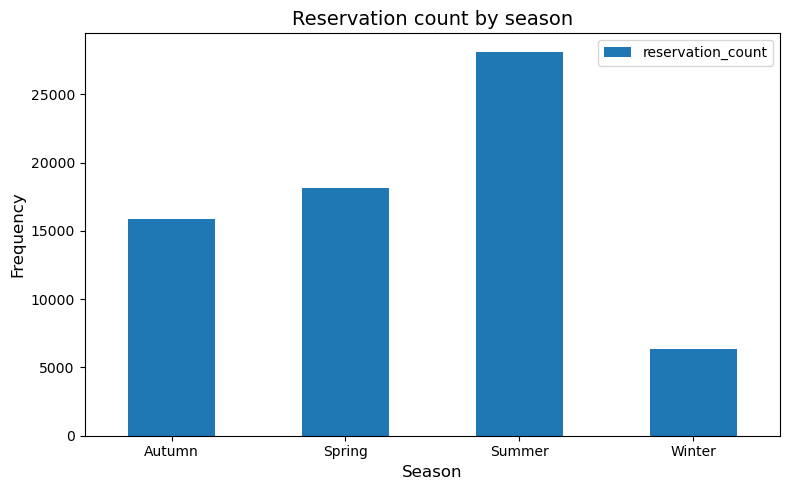

In [34]:
# 使用 bar plot 並設置 x 軸為 'season'
seasonal_reservation.plot(kind='bar', x='season', y='reservation_count', figsize=(8, 5))

# 設置標題和標籤
plt.title('Reservation count by season', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=0)  # 設置 x 軸標籤的角度
plt.tight_layout()

# 顯示圖表
plt.show()

In [35]:
# 從原始數據中提取月份，並新增到 DataFrame
data['month'] = data['date'].dt.month

# 按月份分組計算預訂數量
month_reservation = data.groupby('month').size().reset_index(name='reservation_count')
month_reservation

,month,reservation_count
0,1,2121
1,2,1968
2,3,3855
3,4,6124
4,5,8128
5,6,8383
6,7,9340
7,8,10334
8,9,5994
9,10,6106


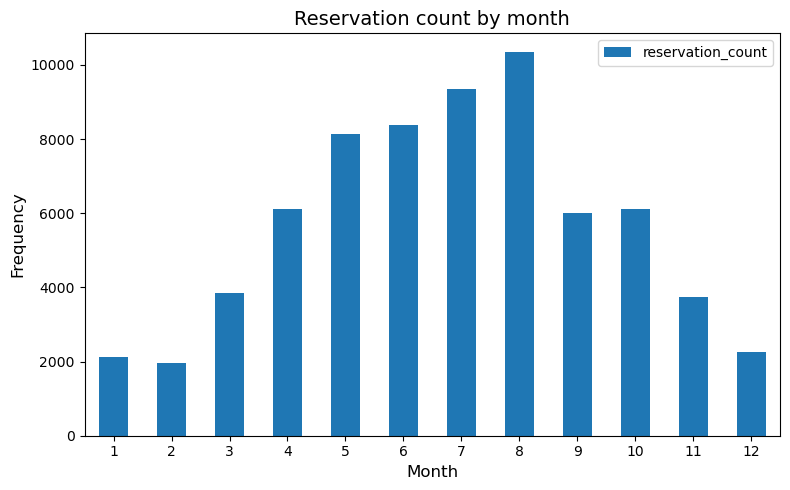

In [36]:
# 使用 bar plot 並設置 x 軸為 'month'
month_reservation.plot(kind='bar', x='month', y='reservation_count', figsize=(8, 5))

# 設置標題和標籤
plt.title('Reservation count by month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=0)  # 設置 x 軸標籤的角度
plt.tight_layout()

# 顯示圖表
plt.show()

### 4. Satisfaction score distribution by host: Compare satisfaction scores across different months, years.

In [38]:
data['month'] = data['date'].dt.month

satisfaction_scores_by_Month = data.groupby('month')[['Satisfaction_Score_5']].agg('mean').reset_index()
satisfaction_scores_by_Month

,month,Satisfaction_Score_5
0,1,3.434473
1,2,3.442915
2,3,3.411853
3,4,3.425700
4,5,3.426378
5,6,3.429515
6,7,3.423376
7,8,3.416638
8,9,3.419271
9,10,3.407496


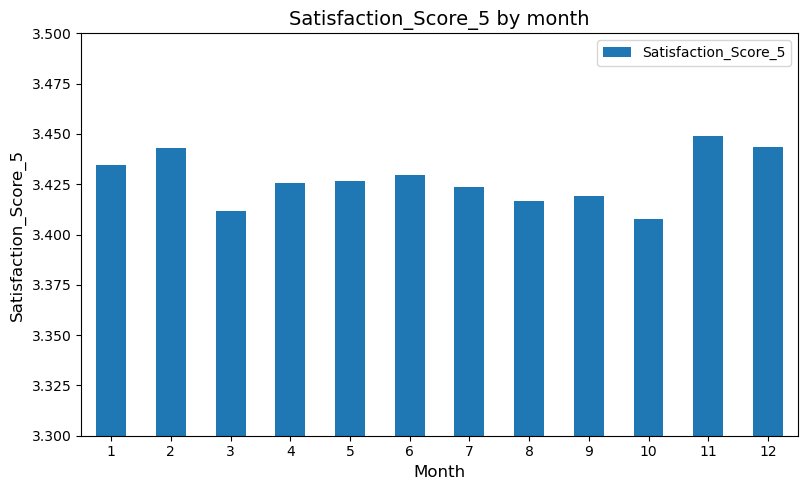

In [39]:
# 使用 bar plot 並設置 x 軸為 'season'
satisfaction_scores_by_Month.plot(kind='bar', x='month', y='Satisfaction_Score_5', figsize=(8, 5))

# 設置標題和標籤
plt.title('Satisfaction_Score_5 by month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Satisfaction_Score_5', fontsize=12)
plt.xticks(rotation=0)  # 設置 x 軸標籤的角度
plt.tight_layout()

# 設置 y 軸範圍
plt.ylim(3.3, 3.5)

# 顯示圖表
plt.show()

In [40]:
data['year'] = data['date'].dt.year

satisfaction_scores_by_Year = data.groupby('year')[['Satisfaction_Score_5']].agg('mean').reset_index()
satisfaction_scores_by_Year

,year,Satisfaction_Score_5
0,2009,3.635576
1,2010,3.494236
2,2011,3.433688
3,2012,3.425029
4,2013,3.425244
5,2014,3.414244
6,2015,3.410419
7,2016,3.437333


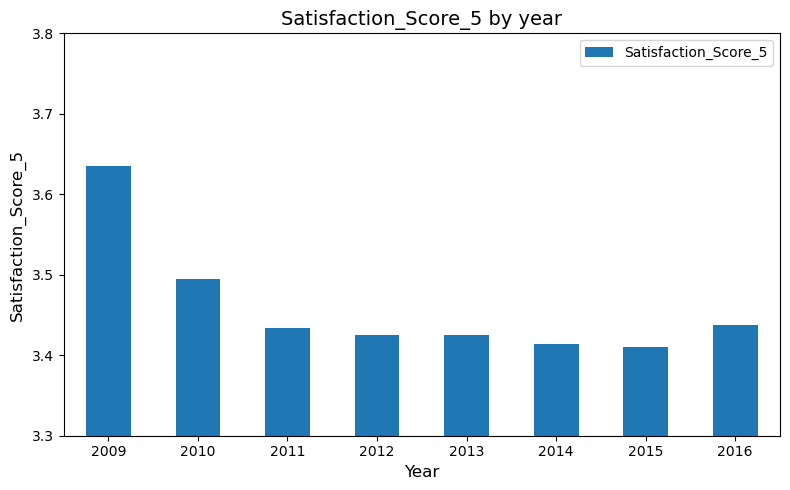

In [41]:
# 使用 bar plot 並設置 x 軸為 'year'
satisfaction_scores_by_Year.plot(kind='bar', x='year', y='Satisfaction_Score_5', figsize=(8, 5))

# 設置標題和標籤
plt.title('Satisfaction_Score_5 by year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Satisfaction_Score_5', fontsize=12)
plt.xticks(rotation=0)  # 設置 x 軸標籤的角度
plt.tight_layout()

# 設置 y 軸範圍
plt.ylim(3.3, 3.8)

# 顯示圖表
plt.show()

# c) Visualization Analysis

### 1. Satisfaction and recommendation score charts: Present the distribution of these scores in visual charts.

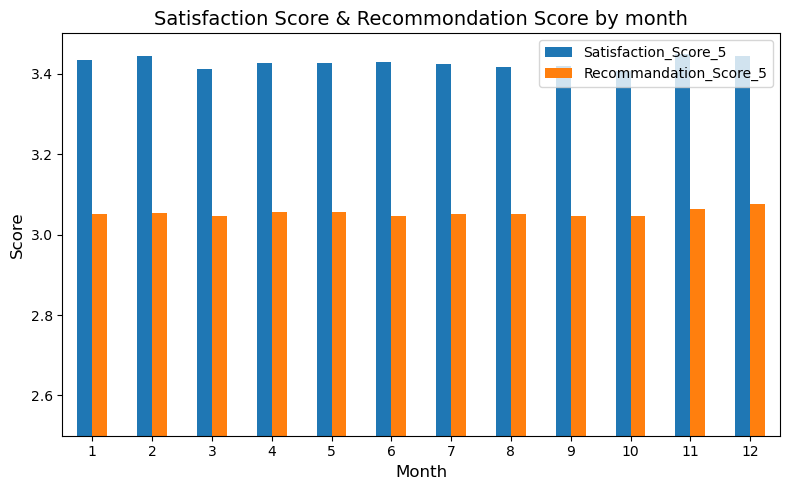

In [44]:
data['month'] = data['date'].dt.month
Sat_recom_by_month = data.groupby('month')[['Satisfaction_Score_5', 'Recommandation_Score_5']].mean()

Sat_recom_by_month.plot(kind = 'bar', figsize=(8, 5))

# 設置標題和標籤
plt.title('Satisfaction Score & Recommondation Score by month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=0)  # 設置 x 軸標籤的角度
plt.tight_layout()

plt.ylim(2.5, 3.5)

plt.show()

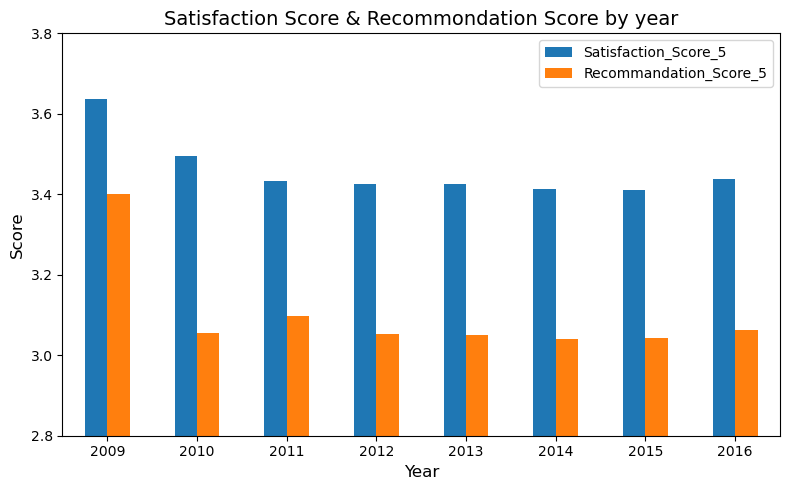

In [45]:
data['year'] = data['date'].dt.year
Sat_recom_by_year = data.groupby('year')[['Satisfaction_Score_5', 'Recommandation_Score_5']].mean()

Sat_recom_by_year.plot(kind = 'bar', figsize=(8, 5))

# 設置標題和標籤
plt.title('Satisfaction Score & Recommondation Score by year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=0)  # 設置 x 軸標籤的角度
plt.tight_layout()

plt.ylim(2.8, 3.8)

plt.show()

### 2. Customer return frequency: Use bar or histograms to visualize the number of customers likely to return by year

In [47]:
# 計算每年的返回顧客數量
customer_return_freq = data[data['Comeback'] == 'Comeback'].groupby('year').size().reset_index(name='return_count')

# 查看結果
print(customer_return_freq)

   year  return_count
0  2009            14
1  2010           106
2  2011           316
3  2012           640
4  2013          1446
5  2014          4511
6  2015         11665
7  2016         15237


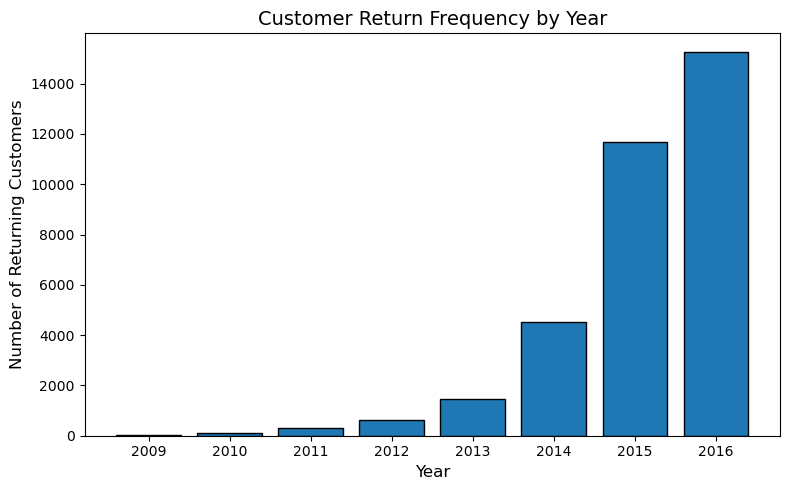

In [48]:
import matplotlib.pyplot as plt

# 繪製柱狀圖
plt.figure(figsize=(8, 5))
plt.bar(customer_return_freq['year'], customer_return_freq['return_count'], edgecolor='black')

# 添加標題和標籤
plt.title('Customer Return Frequency by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Returning Customers', fontsize=12)
plt.xticks(customer_return_freq['year'], rotation=0)  # 保持 x 軸標籤水平
plt.tight_layout()

# 顯示圖表
plt.show()


### 3. Booking trends: Create a timeline (by month / year visualization to show peak and low seasons for bookings.

In [50]:
# 按月份計算預訂數量
booking_by_month = data.groupby(data['date'].dt.month).size().reset_index(name='booking_count')

# 設置月份名稱
booking_by_month['month_name'] = booking_by_month['date'].apply(lambda x: pd.Timestamp(month=x, day=1, year=2000).strftime('%B'))

# 查看結果
print(booking_by_month)

    date  booking_count month_name
0      1           2121    January
1      2           1968   February
2      3           3855      March
3      4           6124      April
4      5           8128        May
5      6           8383       June
6      7           9340       July
7      8          10334     August
8      9           5994  September
9     10           6106    October
10    11           3740   November
11    12           2255   December


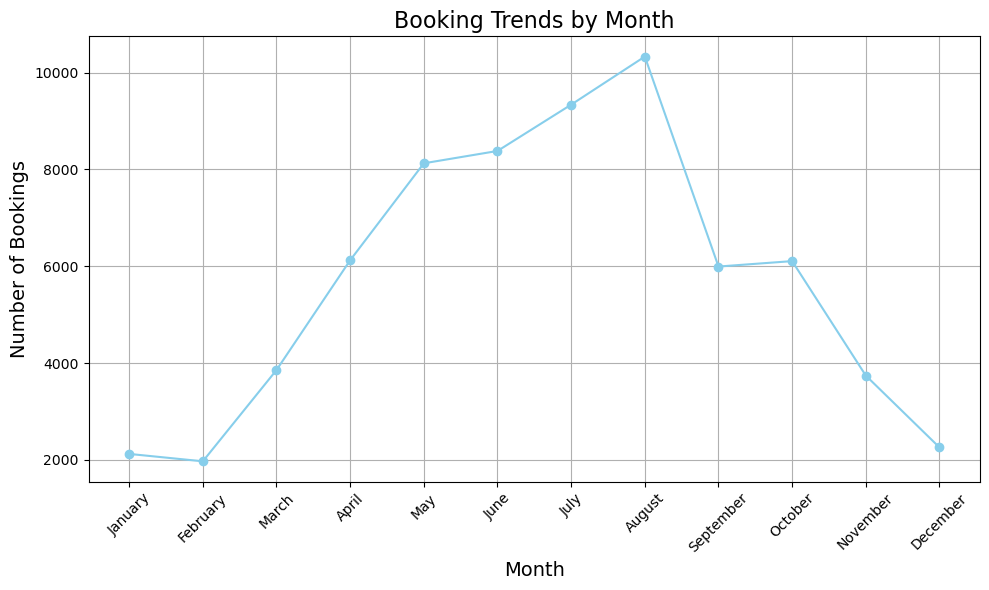

In [51]:
import matplotlib.pyplot as plt

# 排序月份順序
booking_by_month = booking_by_month.sort_values('date')

# 繪製折線圖
plt.figure(figsize=(10, 6))
plt.plot(booking_by_month['month_name'], booking_by_month['booking_count'], marker='o', color='skyblue')

# 添加標題和標籤
plt.title('Booking Trends by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Bookings', fontsize=14)
plt.grid(True)
plt.xticks(rotation=45)  # x 軸標籤傾斜
plt.tight_layout()

# 顯示圖表
plt.show()


### 4. Sentiment comparison by host: Present sentiment scores by host to identify the most appreciated hosts.

In [53]:
# 按 listing_id分組
sentiment_by_host = data.groupby('listing_id')[['Sentiment_Score']].count().reset_index()

# 查看結果
print(sentiment_by_host)

      listing_id  Sentiment_Score
0           3353               34
1           5506               37
2           6695               47
3           6976               41
4           8792               18
...          ...              ...
2824    14813006                1
2825    14823724                1
2826    14842237                1
2827    14843050                2
2828    14843783                3

[2829 rows x 2 columns]


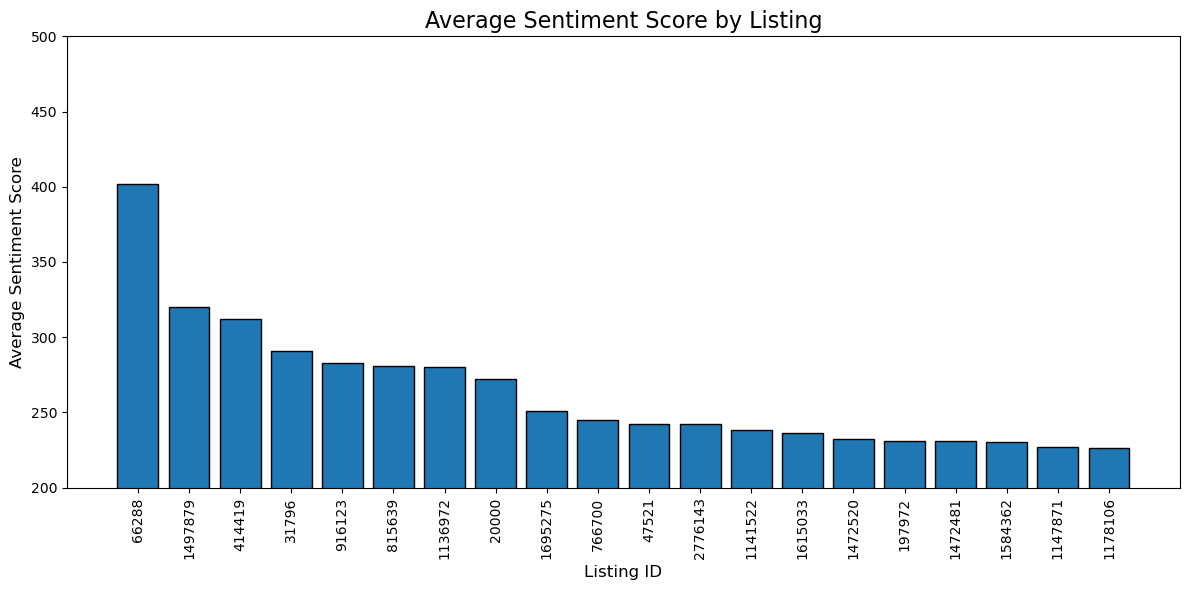

In [54]:
import matplotlib.pyplot as plt

# 按平均情感分數排序
sentiment_by_host = sentiment_by_host.sort_values('Sentiment_Score', ascending=False)

# 選取情感分數最高的前 20 個房源
top_20_listings = sentiment_by_host.nlargest(20, 'Sentiment_Score')

# 繪製條形圖
plt.figure(figsize=(12, 6))
plt.bar(top_20_listings['listing_id'].astype(str), top_20_listings['Sentiment_Score'], edgecolor='black')

# 添加標題和標籤
plt.title('Average Sentiment Score by Listing', fontsize=16)
plt.xlabel('Listing ID', fontsize=12)
plt.ylabel('Average Sentiment Score', fontsize=12)

# x 軸標籤旋轉以避免重疊
plt.xticks(rotation=90)

# 設置 y 軸範圍
plt.ylim(200, 500)

# 調整布局
plt.tight_layout()

# 顯示圖表
plt.show()

# d)Predictive Analytics

### 1. Modeling customer return: Use satisfaction and recommendation scores and others variables to predict the likelihood of customer return (Comeback).

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Data preparation
data['Comeback'] = data['Comeback'].map({'Comeback': 1, 'No Comeback': 0})  # Convert to numerical

# Feature selection
X = data[['Satisfaction_Score_5', 'Recommandation_Score_5', 'Sentiment_Score']]
y = data['Comeback']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))


Accuracy: 0.9998536942209217
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6923
           1       1.00      1.00      1.00      6747

    accuracy                           1.00     13670
   macro avg       1.00      1.00      1.00     13670
weighted avg       1.00      1.00      1.00     13670

AUC-ROC: 0.9999999357732106


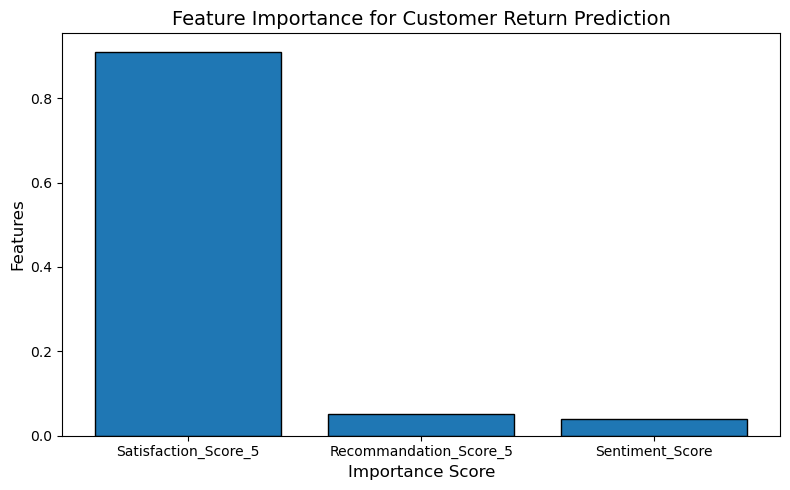

In [58]:
# 特徵重要性
importance = model.feature_importances_

features = ['Satisfaction_Score_5', 'Recommandation_Score_5', 'Sentiment_Score']

plt.figure(figsize=(8, 5))
plt.bar(features, importance, edgecolor='black')
plt.title('Feature Importance for Customer Return Prediction', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

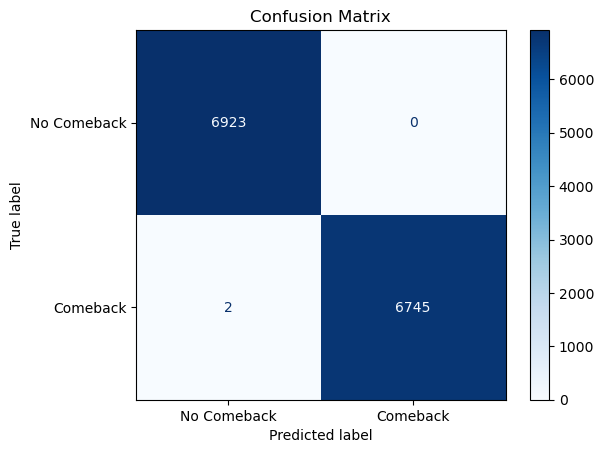

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 計算混淆矩陣
cm = confusion_matrix(y_test, y_pred)

# 視覺化混淆矩陣
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Comeback', 'Comeback'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

### 2. Factors affecting satisfaction: Analyze which factors most influence satisfaction scores and Satisfaction_Livel

In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = data[['Recommandation_Score_5', 'Sentiment_Score', 'Satisfaction_Score_5']]
data['Customer_numeric'] = data['Comeback'].apply(lambda x: 1 if x == "Comeback" else 0)

# 分割數據
X_train, X_test, y_train, y_test = train_test_split(X, data['Customer_numeric'], test_size=0.2, random_state=42)

# 建立回歸模型
reg = LinearRegression()
reg.fit(X_train, y_train)

# 輸出每個特徵的係數
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': reg.coef_})
print(coefficients)

# 評估模型
y_pred = reg.predict(X_test)
from sklearn.metrics import r2_score, mean_squared_error
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")


                  Feature  Coefficient
0  Recommandation_Score_5          0.0
1         Sentiment_Score          0.0
2    Satisfaction_Score_5          0.0
R2 Score: 1.00
Mean Squared Error: 0.00
